### Kategorisk data

Kategorier av vilket slag som helst kan läggas till eller samlas i datan. Så länge varje rad har något tillhörande värde går det bra att lägga till i en modell. Kategorier representeras i allmänhet med heltal, till exempel $0$ för "kort", $1$ för "medium" och $2$ för "lång". Notera att i detta exempel finns en inneboende storleksordning mellan kategorierna. Lång ger en dubbelt så stor respons som medium. Om det inte finns ett sådant förhållande behöver vi koda kategorierna på något annat sätt.

In [962]:
import pandas as pd

df = pd.read_csv("../Data/paint.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Relative humidity (%)  31 non-null     float64
 1   type                   31 non-null     int64  
 2   Evaporation (% wt)     31 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 876.0 bytes


Färg-exemplet har en kolonn 'type' med heltalsvärden.

array([[<Axes: title={'center': 'Relative humidity (%)'}>,
        <Axes: title={'center': 'type'}>],
       [<Axes: title={'center': 'Evaporation (% wt)'}>, <Axes: >]],
      dtype=object)

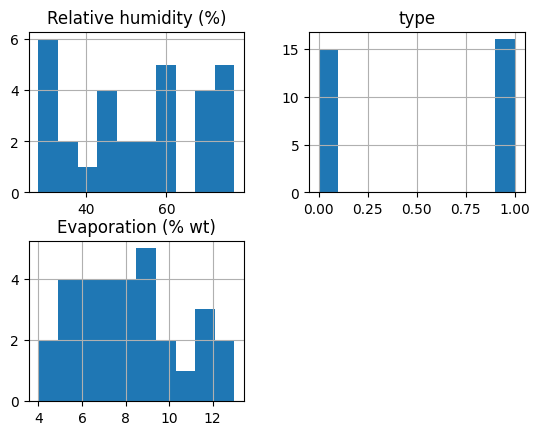

In [963]:
df.hist()

Det finns två färger i exemplet, kodat som 0 eller 1. Med denna datta kan vi förvänta oss bäst resultat om vi förutsäger avdunstning givet luftfuktighet och typ, utifrån ovanstående fördelningar.

In [964]:
df.corr()

,Relative humidity (%),type,Evaporation (% wt)
Relative humidity (%),1.000000,-0.139497,-0.616373
type,-0.139497,1.000000,0.780310
Evaporation (% wt),-0.616373,0.780310,1.000000


Både typ och luftfuktighet korrelerar till avdunstingen men inte till varandra. Vi kan försöka förutsäga luftfuktigheten genom att mäta avdunstningen, men mätdatan ser inte särskilt normal ut så responsen vi fångar kommer få dåliga resultat på okänd data. Om vi mätte luftfuktighet mer systematiskt och över mycket längre tid skulle det finnas ett medelvärde (väntevärdet vid någon enskild mätning) som övriga värden normalfördelade kring -- förutsatt att vi mätte under tillräckligt lång tid för att säsongsvariationer och liknande fångas i medlet. Att det verkligen blir så rent statistiskt är vad centrala gränsvärdessatsen visar!

In [965]:
import numpy as np

X, y = df.drop("Evaporation (% wt)", axis=1), df["Evaporation (% wt)"]
X = np.column_stack([np.ones(y.shape[0]), X["Relative humidity (%)"], X['type']])
b = np.linalg.pinv(X.T @ X) @ X.T @ y

In [966]:
b

array([10.32337931, -0.07705959,  3.42002324])

Det återstår att tolka vad ovanstående betyder. Men låt oss först se om regressionen gav något alls vettigt rent statistiskt.

In [967]:
import scipy.stats as stats

d = len(b)-1
n = len(y)
SSE = np.sum(np.square(y - (X @ b)))
var = SSE/(n-d-1)
S = np.sqrt(var)

# Regression sum of squares, total variance
SSR = np.sum(b*(X.T @ y)) - (np.square(np.sum(y))/n)
Syy = np.sum(np.square(y)) - (np.square(np.sum(y))/n)

# Significant regression test, test rejects for large values
sig_statistic = (SSR/d)/var

# P score for H0 in significance test is very close to 0,
# -- we reject the hypothesis that no variable is relevant
p_sig = stats.f.sf(sig_statistic, d, n-d-1)

p_sig

np.float64(3.320296423416697e-13)

Definitivt signifikant. Vad för konfidens kan vi välja?

In [968]:
Rsq = SSR/Syy

Rsq

np.float64(0.8715732507382263)

Inte så bra. Vi når inte en 90% kondfidensnivå, men högre än 80% täckning brukar kunna vara användbart i praktiken i ML. Så låt oss fortsätta. Finns det åtminstone statistiskt stöd för en skillnad mellan typerna?

In [969]:
c = np.linalg.inv(X.T @ X) * var

# Is there a statisticall significant difference between types?
b2_statistic = b[2] / (S*np.sqrt(c[2, 2]))
# Two-sided test (rejects for large or small)
p_b2 = 2 * min(stats.t.cdf(b2_statistic, n-d-1), stats.t.sf(b2_statistic, n-d-1))
print(p_b2)

5.197632893027597e-12


Starkt stöd för en skillnad mellan typerna. Men hur tolkar vi ett resultat med kategorisk data? Det är egentligen _två_ modeller i detta fall. Det blir faktiskt en modell per kategori! Låt oss undersöka detta.

$$
Y = \beta_0 + \beta_1x + \beta_2t
$$


$$
Y = 10.323 -0.077 x + 3.42t
$$

$$
Y = 10.323 + 3.42*1 -0.077 x 
$$
$$
Y = 10.323 + 3.42*0-0.077 x 
$$

Dvs parallella linjer!

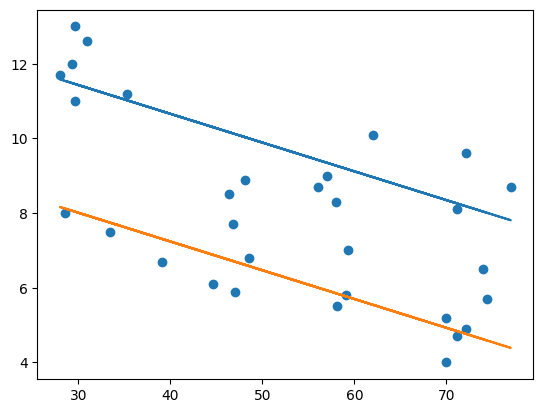

In [970]:
import matplotlib.pyplot as plt

modA = np.append(b[0] + b[2], b[1:2]) # type = 1, ie add last coefficient to b0
modB = b[0:2] # type 0
Xr = X[:, 0:2]
x = Xr[:, 1:2]
plt.scatter(x, y)
plt.plot(x, Xr @ modA)
plt.plot(x, Xr @ modB)

### Dummy encoding,  One-hot encoding

I ovanstående exempel användes _dummy_ encoding. En variabel spårade två typer. Om det hade funnits tre typer hade det behövts två variabler, för tillstånden 0 0, 1 0, och 0 1. Men nu skulle 1 1 innebära att typ två och tre, men inte ett, var närvarande. Så vi skulle behöva försäkra oss om att kodningen används korrekt.

Ett annat alternativ är att helt enkelt ha en [0,1] variabel för varje kategori. Då kan vi naturligt också indikera att flera kategorier är närvarande samtidigt. Detta är _one-hot_ encoding. Men nu ökar dimensionaliteten för vårt problem med 1 per kategori! Och de flesta av dessa dimensioner är _tomma_ (0:or i alla utom en)! Detta problem med _glesa representationer_ återkommer vi till i både ML och DL kurserna. Men det skall sägas att många nuvarande ML system, som till exempel chatbottar, verkligen har gigantiska one-hot vektorer i indatan (hundratusentals och miljontals långa), där varje 1:a motsvarar att en viss _token_ finns i datan. 

In [971]:

df['type2'] = df.apply(lambda row: int(1 - row['type']), axis=1)

X, y = df.drop("Evaporation (% wt)", axis=1), df["Evaporation (% wt)"]
X = np.column_stack([np.ones(y.shape[0]), X["Relative humidity (%)"], X['type'], X['type2']])
b = np.linalg.pinv(X.T @ X) @ X.T @ y

In [972]:
b

array([ 8.02226062, -0.07705959,  5.72114193,  2.30111869])

Det blev lite annorlunda, men kom ihåg att nu är _antingen_ intercepten $8+5.7 \simeq 13.7$ eller $8+2.3\simeq 10.3$ vilket motsvarar tidigare regression. Vi har nu också ett hypotetiskt fall när ingen av typerna är närvarande, men det är oklart vad det skulle betyda för denna data!

Tolkningen avgör vilken kodning som är mest lämplig!

In [973]:
df = df.drop("type2", axis=1)

## Klassificering

Kan vi avgöra typ från de två övriga parametrarna? Låt oss bara försöka naivt och se vad som händer!

In [974]:

X, y = df.drop("type", axis=1), df["type"]
X = np.column_stack([np.ones(y.shape[0]), X["Relative humidity (%)"], X["Evaporation (% wt)"]])
b = np.linalg.pinv(X.T @ X) @ X.T @ y

In [975]:
b

array([-2.23971631,  0.01697468,  0.23183714])

In [976]:
SSE = np.sum(np.square(y - (X @ b)))
np.sqrt(SSE)

np.float64(1.253890812783551)

Hur tolkar vi ens det här? Hur ser vi om det är rätt?

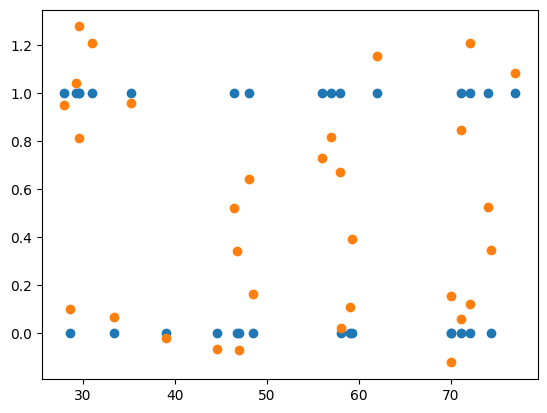

In [977]:
plt.scatter(x, y)
plt.scatter(x, X @ b)

Det här blev svårtolkat. Men redan i programmeringskursen löste ni detta problem! Det är dock lite för spretigt för att använda KNN. Låt oss först återgå till de två modellerna från tidigare men separera ut en valideringsmängd.

In [978]:
validation = df.sample(frac=0.4, random_state=42, replace=False)
df = df.drop(validation.index)

X, y = df.drop("Evaporation (% wt)", axis=1), df["Evaporation (% wt)"]
X = np.column_stack([np.ones(y.shape[0]), X["Relative humidity (%)"], X['type']])
b = np.linalg.pinv(X.T @ X) @ X.T @ y

In [979]:
modA = np.append(b[0] + b[2], b[1:2]) # type = 1, ie add last coefficient to b0
modB = b[0:2]

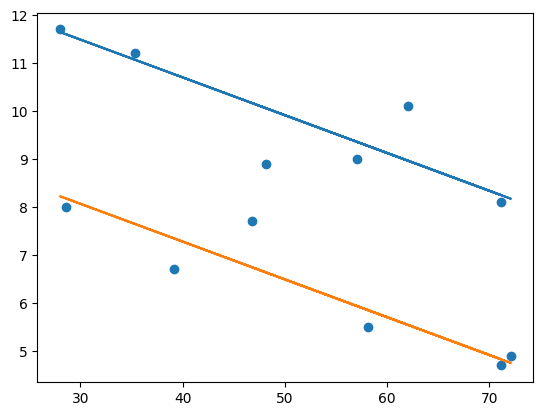

In [980]:
X, y = validation.drop(["Evaporation (% wt)", "type"], axis=1).to_numpy(), validation["Evaporation (% wt)"].to_numpy()
Xb = np.column_stack([np.ones(y.shape[0]), X])

plt.scatter(X, y)
plt.plot(X, Xb @ modA)
plt.plot(X, Xb @ modB)


För att klassificera datan förutsäger vi $\hat{y}$, dvs avdunstningen, med vardera modell och väljer den vars kvadrat är närmst $y$ värdet i valideringsdatan. Vi väljer kvadraten för att straffa stora avstånd och belöna små avstånd.

In [981]:
def classify(x, y):
    row_x = [1.0, x]
    ea_sq = np.square(y - np.dot(row_x, modA))
    eb_sq = np.square(y - np.dot(row_x, modB))
    return ea_sq < eb_sq

In [982]:
# classify
Y = validation["Evaporation (% wt)"]
X = validation["Relative humidity (%)"]
T = validation["type"]
correct = True
for i, x in enumerate(X):
    correct &= T.iloc[i] == classify(x, Y.iloc[i])
print(f"Alla klassifikationer i valideringsdatan korrekta? {correct}")

Alla klassifikationer i valideringsdatan korrekta? True


Dessa linjer kallas _beslutsgränser_ (decision boundaries). Exemplet ovan kallas en _linjär klassificerare_, av förståeliga skäl.

### Icke-linjäritet

Som vi nämnt kan vi _linjärisera_ även polynom och interaktionseffekter, eftersom deras väntevärden ändå är linjära. Hittils har vi bara sett kategorisk data påverka _bias_ i modellen, där varje modell har sin egen förfördelning bort från medlet (dvs de är _affina_ transformationer). Vi kan tolka one-hot coding i en modell som den homogena och partikulärlösningarna till ett allmänt ekvationssystem $\boldsymbol{\beta}_h + \boldsymbol{\beta}_p = X^{-1}Y$ där $\boldsymbol{\beta}_h$ är lösningen till det linjära ekvationssystemet-- dvs precis då $\beta_0 = 0$.

Vi kan även lägga till kategoriska beroenden på _lutningen_ hos en linje. Detta är helt enkelt en interaktionseffekt!

$$
Y = \beta_0 + \beta_1X_1  + \beta_2C_1 + \beta_3C_1X_1
$$

In [983]:
X, y = df.drop(["Evaporation (% wt)"], axis=1), df["Evaporation (% wt)"]
y0 = y[df['type'] == 0]
y1 = y[df['type'] == 1]
X0 = X[df['type'] == 0]
X1 = X[df['type'] == 1]
X['type_k'] = df.apply(lambda row: row['type']*row['Relative humidity (%)'], axis=1)
X.insert(0, "Intercept", 1)
X.tail(), X.head()

(    Intercept  Relative humidity (%)  type  type_k
 22          1                   74.4     0     0.0
 25          1                   44.6     0     0.0
 26          1                   33.4     0     0.0
 28          1                   59.1     0     0.0
 30          1                   47.0     0     0.0,
    Intercept  Relative humidity (%)  type  type_k
 1          1                   29.6     1    29.6
 2          1                   31.0     1    31.0
 3          1                   58.0     1    58.0
 5          1                   72.1     1    72.1
 6          1                   74.0     1    74.0)

In [984]:
X, y = X.to_numpy(), y.to_numpy()
b = np.linalg.pinv(X.T @ X) @ X.T @ y

In [985]:
b

array([ 9.02470155, -0.05376716,  5.3716895 , -0.03582312])

In [986]:
modA = np.append(b[0] + b[2], b[1] + b[3])
modB = b[0:2]
modA, modB

(array([14.39639104, -0.08959028]), array([ 9.02470155, -0.05376716]))

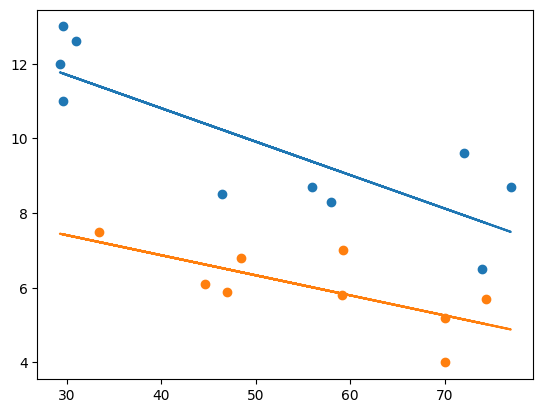

In [987]:
Xb = X[:, 0:2]
X = X[:, 1]
X0 = X0.iloc[:, 0]
X1 = X1.iloc[:, 0]
plt.scatter(X1, y1)
plt.scatter(X0, y0)
plt.plot(X, Xb @ modA)
plt.plot(X, Xb @ modB)

In [988]:
Y = validation["Evaporation (% wt)"]
X = validation["Relative humidity (%)"]
T = validation["type"]
correct = True
for i, x in enumerate(X):
    correct &= T.iloc[i] == classify(x, Y.iloc[i])
print(f"Alla klassifikationer i valideringsdatan korrekta? {correct}")

Alla klassifikationer i valideringsdatan korrekta? True


En utmärkt övning är att spåra SSE under klassificeringen och beräkna MSE. Jämför MSE:n mellan de två regressionerna!